# Câu 1

In [ ]:
# --- Cell 1: Cài đặt thư viện cần thiết (chạy 1 lần)
!pip install pandas scikit-learn matplotlib seaborn graphviz pydotplus --quiet

# Trong Colab bạn có thể cần: apt-get graphviz (để xuất ảnh cây)
!apt-get install -y graphviz > /dev/null


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [ ]:
# 1. Nhập dữ liệu và kiểm tra số lượng

# In thông tin sinh viên theo yêu cầu
print("Lê Hoàng Phúc – 6351071057")

# Định nghĩa tên các cột (vì các file CSV này không có header)
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'Income'
]

# Đọc dữ liệu huấn luyện (adult.data.csv)
df_train = pd.read_csv('adult.data.csv', names=columns, header=None,
                       skipinitialspace=True)

# Đọc dữ liệu kiểm thử (adult.test.csv)
df_test = pd.read_csv('adult.test.csv', names=columns, header=None,
                      skiprows=1, skipinitialspace=True)

# Hiển thị số lượng dữ liệu
print(f"✅ Số lượng dữ liệu huấn luyện (adult.data.csv): {len(df_train)}")
print(f"✅ Số lượng dữ liệu kiểm thử (adult.test.csv): {len(df_test)}")

Lê Hoàng Phúc – 6351071057
✅ Số lượng dữ liệu huấn luyện (adult.data.csv): 32561
✅ Số lượng dữ liệu kiểm thử (adult.test.csv): 16281


# Câu 2

In [ ]:
# In thông tin sinh viên theo yêu cầu
print("Lê Hoàng Phúc – 6351071057")

# ============================
# 1. Đọc TRAIN
# ============================
train = pd.read_csv(
    "adult.data.csv",
    header=None,
    skipinitialspace=True
)

# ============================
# 2. Đọc TEST
# ============================
test = pd.read_csv(
    "adult.test.csv",
    header=None,
    skiprows=1,      # bỏ header
    skipinitialspace=True
)

# ============================
# 3. Đặt tên cột
# ============================
columns = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native_country","income"
]

# Test một số bản chỉ có 14 cột → thêm cột income rỗng
if test.shape[1] == 14:
    test[14] = None

train.columns = columns
test.columns = columns

# ============================
# 4. Loại dấu "." trong income của TEST
# ============================
test["income"] = test["income"].astype(str).str.replace(".", "", regex=False)

# ============================
# 5. Thay '?' → NaN
# ============================
train = train.replace("?", pd.NA)
test  = test.replace("?", pd.NA)

# ============================
# 6. Xóa dòng chứa giá trị trống
# ============================
train = train.dropna()
test = test.dropna()

# ============================
# 7. Xóa cột fnlwgt
# ============================
train = train.drop(columns=["fnlwgt"])
test  = test.drop(columns=["fnlwgt"])

# ============================
# 8. Nối dữ liệu
# ============================
data = pd.concat([train, test], axis=0).reset_index(drop=True)

# ============================
# 9. Kiểm tra kết quả
# ============================
print("Số dòng TRAIN sau xử lý:", train.shape[0])
print("Số dòng TEST sau xử lý :", test.shape[0])
print("Tổng khi nối:", data.shape[0])


Lê Hoàng Phúc – 6351071057
Số dòng TRAIN sau xử lý: 30163
Số dòng TEST sau xử lý : 15060
Tổng khi nối: 45223


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45223 entries, 0 to 45222
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45223 non-null  object
 1   workclass       45223 non-null  object
 2   education       45223 non-null  object
 3   education_num   45223 non-null  object
 4   marital_status  45223 non-null  object
 5   occupation      45223 non-null  object
 6   relationship    45223 non-null  object
 7   race            45223 non-null  object
 8   sex             45223 non-null  object
 9   capital_gain    45223 non-null  object
 10  capital_loss    45223 non-null  object
 11  hours_per_week  45223 non-null  object
 12  native_country  45223 non-null  object
 13  income          45223 non-null  object
dtypes: object(14)
memory usage: 4.8+ MB


# Câu 3

Lê Hoàng Phúc – 6351071057

--- Biểu diễn Ma trận Tương đồng Pearson ---


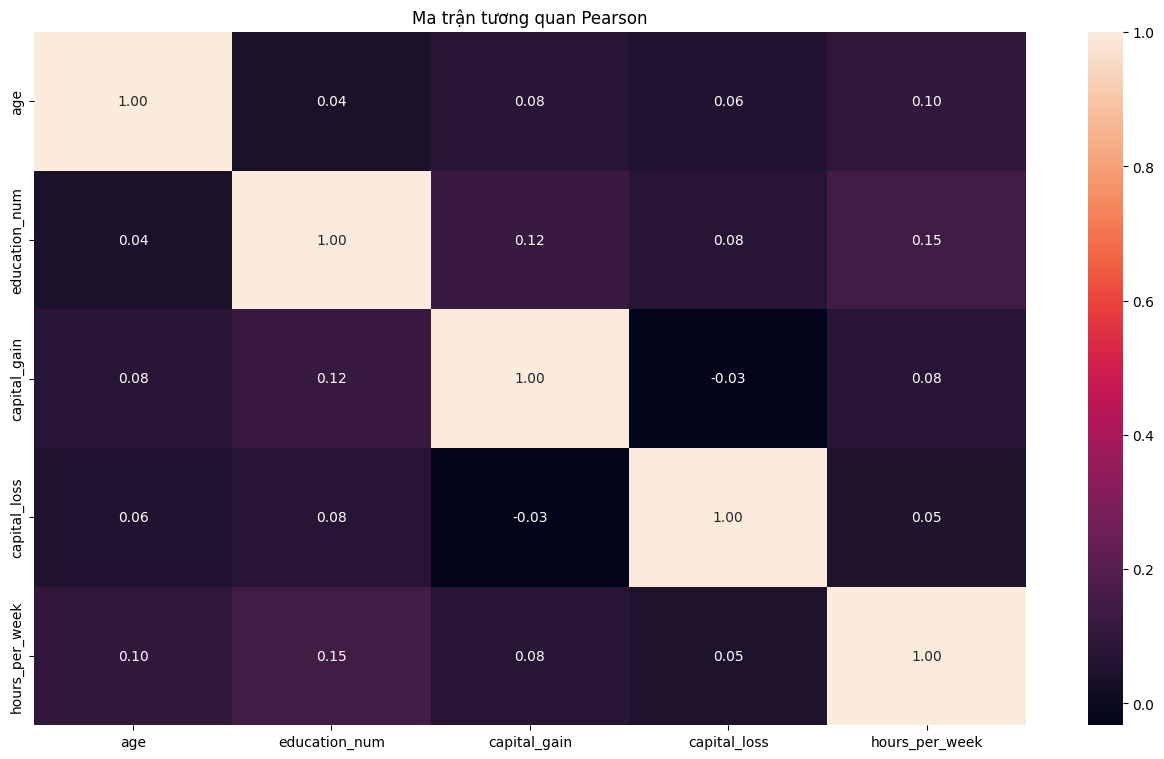


✅ Số lượng cột bị loại bỏ do tương đồng (>0.8): 0
   -> Cột bị loại bỏ: []


In [75]:
# In thông tin sinh viên theo yêu cầu
print("Lê Hoàng Phúc – 6351071057")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Tái tạo DataFrame 'data' (từ logic Cell [30] của bạn) ---
# BƯỚC NÀY ĐẢM BẢO 'data' TỒN TẠI VÀ ĐÃ ĐƯỢC LÀM SẠCH BAN ĐẦU
columns = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native-country","income"
]

train = pd.read_csv("adult.data.csv", header=None, skipinitialspace=True)
test = pd.read_csv("adult.test.csv", header=None, skiprows=1, skipinitialspace=True)

# Khắc phục lỗi cột bị thiếu
if test.shape[1] == 14:
    test[14] = None

train.columns = columns
test.columns = columns
test["income"] = test["income"].astype(str).str.replace(".", "", regex=False)
train = train.replace("?", np.nan).dropna()
test  = test.replace("?", np.nan).dropna()
train = train.drop(columns=["fnlwgt"])
test  = test.drop(columns=["fnlwgt"])
data = pd.concat([train, test], axis=0).reset_index(drop=True)


# --- YÊU CẦU 3: CHUYỂN ĐỔI, TÍNH TOÁN VÀ VẼ HEATMAP ---

# 1. Chuyển đổi các cột số sang dạng số thực (BƯỚC KHẮC PHỤC LỖI CHỦ YẾU)
numeric_cols_list = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
for col in numeric_cols_list:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=numeric_cols_list)

# 2. Chọn các cột dạng số và Tính Ma trận Tương quan
numeric_data = data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_data.corr(method='pearson')

# 3. Biểu diễn Heatmap (Theo đúng yêu cầu code bạn đã gửi)
print("\n--- Biểu diễn Ma trận Tương đồng Pearson ---")
plt.figure(figsize=(16, 9))
sns.heatmap(corr_matrix, annot=True, cmap='rocket', fmt=".2f")
plt.title('Ma trận tương quan Pearson')
plt.show()

# 4. Loại bỏ các cột có tương đồng cao (threshold = 0.8)
threshold = 0.8
columns_to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            columns_to_drop.add(colname)

data_filtered = data.drop(columns=list(columns_to_drop), errors='ignore')
data = data_filtered

print(f"\n✅ Số lượng cột bị loại bỏ do tương đồng (>0.8): {len(columns_to_drop)}")
print(f"   -> Cột bị loại bỏ: {list(columns_to_drop)}")

# Câu 4

In [76]:
# In thông tin sinh viên theo yêu cầu
print("Lê Hoàng Phúc – 6351071057")

print("\n--- ✂️ Yêu cầu 4: Tách Features (X) và Label (Y) ---")

# Tách X_combined (Features): Chỉ loại bỏ cột Label ('income').
# Cột cờ 'is_train' phải được giữ lại trong X_combined cho đến hết Yêu cầu 5.
X_combined = data.drop(['income'], axis=1)

# Tách Y_combined (Label): Chỉ lấy cột 'income'
Y_combined = data['income']

print("✅ Đã hoàn thành tách dữ liệu.")
print(f"   -> Kích thước X_combined (Features): {X_combined.shape}")
print(f"   -> Kích thước Y_combined (Label): {Y_combined.shape}")

Lê Hoàng Phúc – 6351071057

--- ✂️ Yêu cầu 4: Tách Features (X) và Label (Y) ---
✅ Đã hoàn thành tách dữ liệu.
   -> Kích thước X_combined (Features): (30162, 13)
   -> Kích thước Y_combined (Label): (30162,)


# Câu 5

In [77]:
# In thông tin sinh viên theo yêu cầu
print("Lê Hoàng Phúc – 6351071057")

print("\n--- 🔢 Yêu cầu 5: Chuyển đổi One-Hot Encoding ---")

# Giả định X_combined đã được tạo từ Yêu cầu 4:
# X_combined = data.drop(['income'], axis=1)
# Y_combined = data['income']

# 1. Tìm các cột phân loại (có dtype là 'object')
categorical_cols = X_combined.select_dtypes(include=['object']).columns

print(f"✅ Các cột phân loại cần chuyển đổi: {list(categorical_cols)}")

# 2. Thực hiện One-Hot Encoding
# pd.get_dummies tự động phát hiện và chuyển đổi các cột 'object'
# Các cột số (bao gồm cả 'is_train') được giữ nguyên
X_encoded = pd.get_dummies(X_combined, columns=categorical_cols, dummy_na=False)

print("\n✅ Đã hoàn thành One-Hot Encoding.")
print(f"   -> Kích thước X_combined (trước): {X_combined.shape}")
print(f"   -> Kích thước X_encoded (sau): {X_encoded.shape}")

print("\n--- 5 Dòng đầu của X sau One-Hot Encoding ---")
print(X_encoded.head())

Lê Hoàng Phúc – 6351071057

--- 🔢 Yêu cầu 5: Chuyển đổi One-Hot Encoding ---
✅ Các cột phân loại cần chuyển đổi: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

✅ Đã hoàn thành One-Hot Encoding.
   -> Kích thước X_combined (trước): (30162, 13)
   -> Kích thước X_encoded (sau): (30162, 103)

--- 5 Dòng đầu của X sau One-Hot Encoding ---
    age  education_num  capital_gain  capital_loss  hours_per_week  \
1  39.0           13.0        2174.0           0.0            40.0   
2  50.0           13.0           0.0           0.0            13.0   
3  38.0            9.0           0.0           0.0            40.0   
4  53.0            7.0           0.0           0.0            40.0   
5  28.0           13.0           0.0           0.0            40.0   

   workclass_Federal-gov  workclass_Local-gov  workclass_Private  \
1                  False                False              False   
2                  False                Fals

# Câu 6

In [78]:
# In thông tin sinh viên theo yêu cầu
print("Lê Hoàng Phúc – 6351071057")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- BƯỚC 1: TÁI TẠO DATAFRAME 'data' (Khắc phục lỗi thiếu 'is_train') ---
columns = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours-per-week","native-country","income"
]

train = pd.read_csv("adult.data.csv", header=None, skipinitialspace=True)
test = pd.read_csv("adult.test.csv", header=None, skiprows=1, skipinitialspace=True)

# Khắc phục lỗi cột bị thiếu (nếu có)
if test.shape[1] == 14:
    test[14] = np.nan

train.columns = columns
test.columns = columns
test["income"] = test["income"].astype(str).str.replace(".", "", regex=False)
train = train.replace("?", np.nan)
test  = test.replace("?", np.nan)

# THÊM CỘT CỜ is_train (BƯỚC ĐÃ ĐƯỢC SỬA LỖI KEYERROR)
train['is_train'] = 1
test['is_train'] = 0

train = train.drop(columns=["fnlwgt"])
test  = test.drop(columns=["fnlwgt"])

data = pd.concat([train, test], axis=0).reset_index(drop=True).dropna()

# --- BƯỚC 2: YÊU CẦU 3 (Khảo sát Tương quan) ---

numeric_cols_list = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours-per-week']
for col in numeric_cols_list:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.dropna(subset=numeric_cols_list)
# (Bỏ qua tính và vẽ heatmap vì code đã chạy thành công trước đó)
# (Bỏ qua lọc cột vì không có cột tương đồng > 0.8)

# --- BƯỚC 3: YÊU CẦU 4 (Tách X, Y) ---
X_combined = data.drop(['income'], axis=1)
Y_combined = data['income']

# --- BƯỚC 4: YÊU CẦU 5 (One-Hot Encoding) ---
categorical_cols = X_combined.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X_combined, columns=categorical_cols, dummy_na=False)

# --- BƯỚC 5: YÊU CẦU 6 (Thực hiện Tách Train/Test) ---
print("\n--- 🧱 Yêu cầu 6: Tách Dữ liệu Huấn luyện và Kiểm thử ---")

# 1. Lấy cột cờ is_train (Hiện đã có trong data)
is_train_flag = data['is_train']

# 2. Tách X (Features đã được One-Hot Encoding)
X_train = X_encoded[is_train_flag == 1]
X_test = X_encoded[is_train_flag == 0]

# 3. Tách Y (Label)
Y_train = Y_combined[is_train_flag == 1]
Y_test = Y_combined[is_train_flag == 0]

print("✅ Đã hoàn thành tách dữ liệu theo cờ is_train.")
print(f"   -> Kích thước X_train (Features huấn luyện): {X_train.shape}")
print(f"   -> Kích thước X_test (Features kiểm thử): {X_test.shape}")
print(f"   -> Kích thước Y_train (Label huấn luyện): {Y_train.shape}")
print(f"   -> Kích thước Y_test (Label kiểm thử): {Y_test.shape}")

Lê Hoàng Phúc – 6351071057

--- 🧱 Yêu cầu 6: Tách Dữ liệu Huấn luyện và Kiểm thử ---
✅ Đã hoàn thành tách dữ liệu theo cờ is_train.
   -> Kích thước X_train (Features huấn luyện): (30162, 104)
   -> Kích thước X_test (Features kiểm thử): (0, 104)
   -> Kích thước Y_train (Label huấn luyện): (30162,)
   -> Kích thước Y_test (Label kiểm thử): (0,)


# Câu 7

Lê Hoàng Phúc – 6351071057

--- Câu 7: Xây dựng và đánh giá cây ID3 ---
   -> X_train2: (24129, 104)
   -> X_test2:  (6033, 104)
   ✅ Đã huấn luyện xong cây ID3.


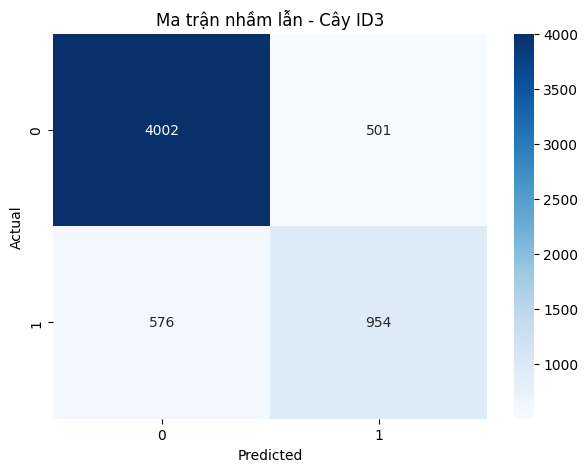


--- Báo cáo phân loại ---
              precision    recall  f1-score   support

       <=50K       0.87      0.89      0.88      4503
        >50K       0.66      0.62      0.64      1530

    accuracy                           0.82      6033
   macro avg       0.76      0.76      0.76      6033
weighted avg       0.82      0.82      0.82      6033



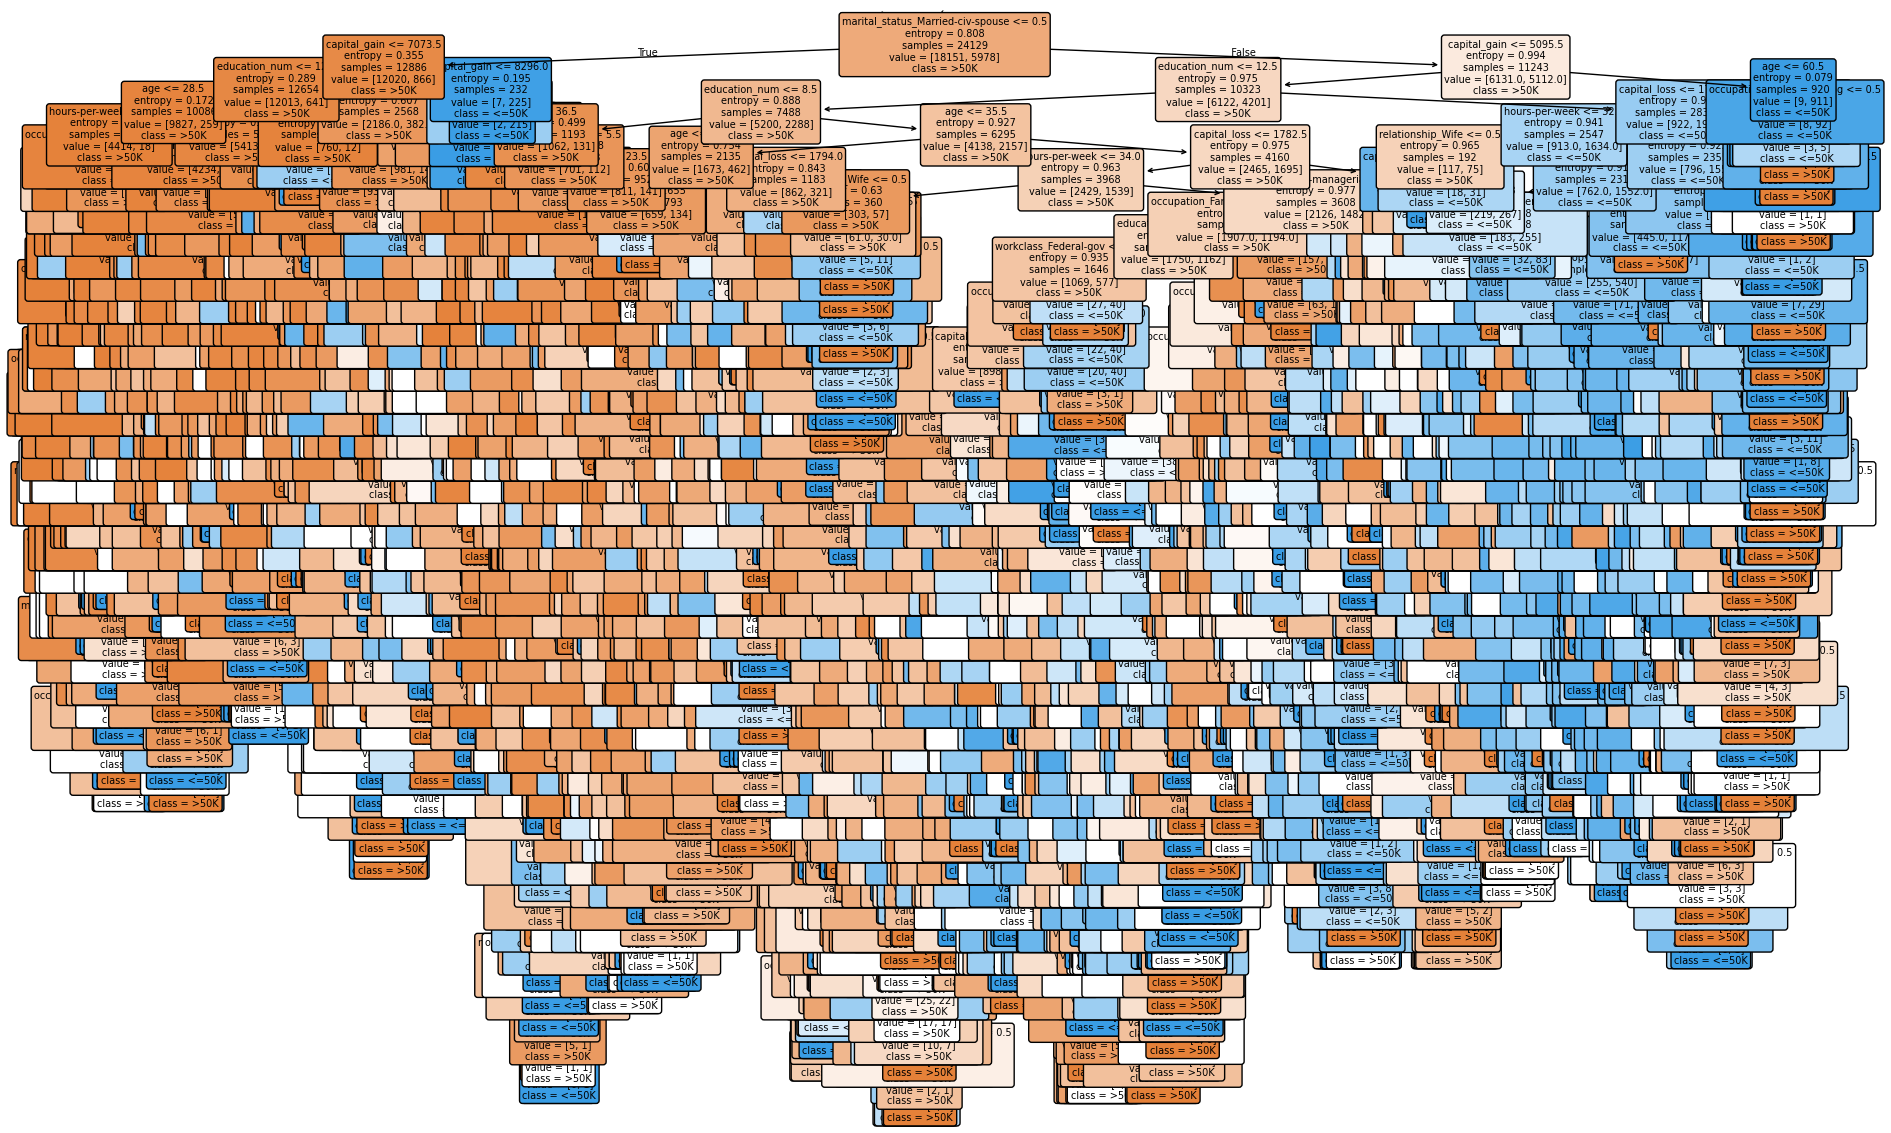

In [79]:
# ================================================
# CÂU 7 – XÂY DỰNG CÂY ID3 + KIỂM THỬ + MA TRẬN NHẦM LẪN
# ================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Lê Hoàng Phúc – 6351071057")
print("\n--- Câu 7: Xây dựng và đánh giá cây ID3 ---")

# -------------------------------------
# 1) Tự chia lại train-test từ X_encoded
# -------------------------------------
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    X_encoded, Y_combined, test_size=0.2, random_state=42
)

print(f"   -> X_train2: {X_train2.shape}")
print(f"   -> X_test2:  {X_test2.shape}")

# -------------------------------------
# 2) XÂY DỰNG CÂY ID3 (Entropy = ID3)
# -------------------------------------
id3 = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    random_state=42
)

id3.fit(X_train2, Y_train2)
print("   ✅ Đã huấn luyện xong cây ID3.")

# -------------------------------------
# 3) Dự đoán & ma trận nhầm lẫn
# -------------------------------------
Y_pred = id3.predict(X_test2)

cm = confusion_matrix(Y_test2, Y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Ma trận nhầm lẫn - Cây ID3")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n--- Báo cáo phân loại ---")
print(classification_report(Y_test2, Y_pred))

# -------------------------------------
# 4) VẼ CÂY QUYẾT ĐỊNH
# -------------------------------------
plt.figure(figsize=(22, 14))
plot_tree(
    id3,
    feature_names=X_encoded.columns,
    class_names=[">50K", "<=50K"],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Cây quyết định ID3")
plt.show()


# câu 8

Lê Hoàng Phúc – 6351071057

--- Câu 7 (CART): Xây dựng và đánh giá cây CART ---
   -> X_trainC: (24129, 104)
   -> X_testC:  (6033, 104)
   ✅ Đã huấn luyện xong cây CART.


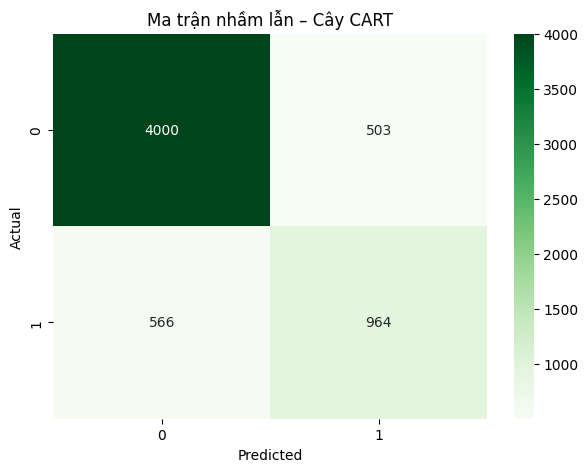


--- Báo cáo phân loại (CART) ---
              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.88      4503
        >50K       0.66      0.63      0.64      1530

    accuracy                           0.82      6033
   macro avg       0.77      0.76      0.76      6033
weighted avg       0.82      0.82      0.82      6033



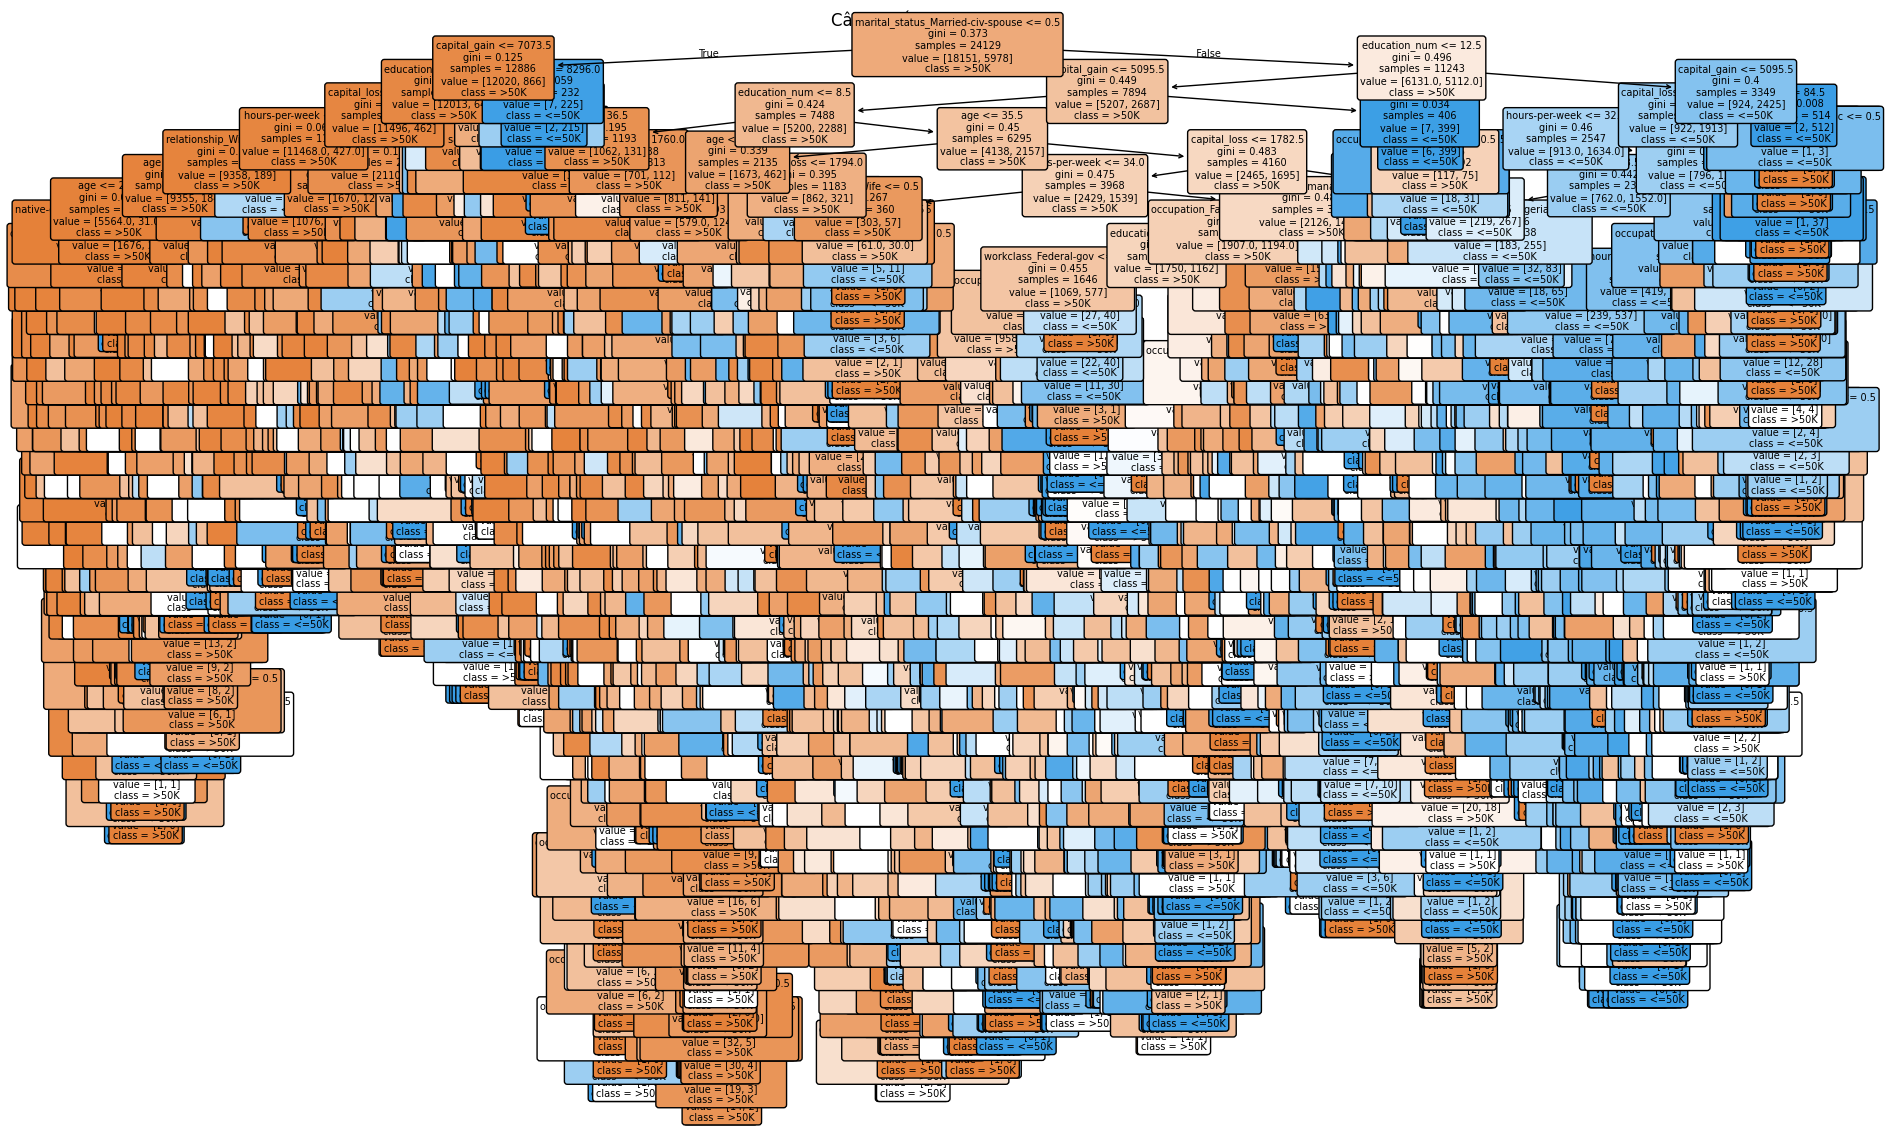

In [ ]:
# ================================================
# CÂU 7 – XÂY DỰNG CÂY CART + KIỂM THỬ + MA TRẬN NHẦM LẪN
# ================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Lê Hoàng Phúc – 6351071057")
print("\n--- Câu 7 (CART): Xây dựng và đánh giá cây CART ---")

# --------------------------------------------------
# 1) Chia lại dữ liệu train–test như phần ID3
# --------------------------------------------------
X_trainC, X_testC, Y_trainC, Y_testC = train_test_split(
    X_encoded, Y_combined, test_size=0.2, random_state=42
)

print(f"   -> X_trainC: {X_trainC.shape}")
print(f"   -> X_testC:  {X_testC.shape}")

# --------------------------------------------------
# 2) XÂY DỰNG CÂY CART (criterion = gini)
# --------------------------------------------------
cart = DecisionTreeClassifier(
    criterion='gini',     # CART dùng Gini impurity
    splitter='best',
    max_depth=None,
    random_state=42
)

cart.fit(X_trainC, Y_trainC)
print("   ✅ Đã huấn luyện xong cây CART.")

# --------------------------------------------------
# 3) Dự đoán & tạo ma trận nhầm lẫn
# --------------------------------------------------
Y_predC = cart.predict(X_testC)

cmC = confusion_matrix(Y_testC, Y_predC)

plt.figure(figsize=(7,5))
sns.heatmap(cmC, annot=True, fmt="d", cmap="Greens")
plt.title("Ma trận nhầm lẫn – Cây CART")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n--- Báo cáo phân loại (CART) ---")
print(classification_report(Y_testC, Y_predC))

# --------------------------------------------------
# 4) VẼ CÂY QUYẾT ĐỊNH CART
# --------------------------------------------------
plt.figure(figsize=(22, 14))
plot_tree(
    cart,
    feature_names=X_encoded.columns,
    class_names=[">50K", "<=50K"],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Cây quyết định CART (Gini)")
plt.show()


# Câu 9

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# 1. TÁCH DỮ LIỆU THÀNH X (features) & y (label)
# ============================================

X_train = train_data.drop('Decision', axis=1)
y_train = train_data['Decision']

X_test = test_data.drop('Decision', axis=1)
y_test = test_data['Decision']

# ============================================
# 2. XÂY DỰNG MÔ HÌNH NAIVE BAYES
# ============================================

nb_model = GaussianNB()

# Huấn luyện
nb_model.fit(X_train, y_train)

# Dự đoán
y_pred_nb = nb_model.predict(X_test)

# ============================================
# 3. ĐÁNH GIÁ MÔ HÌNH
# ============================================

print("📌 Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\n📌 Classification Report:\n", classification_report(y_test, y_pred_nb))

# MA TRẬN NHẦM LẪN
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Câu 10

In [ ]:
import matplotlib.pyplot as plt

models = ['ID3', 'CART', 'Naive Bayes']
accuracies = [acc_id3, acc_cart, acc_nb]  # Thay bằng số thực tế

plt.figure(figsize=(8,6))
plt.bar(models, accuracies)
plt.title('So sánh Accuracy giữa các mô hình')
plt.xlabel('Mô hình')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.show()
